<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/task_40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Insurance Dataset : https://docs.google.com/spreadsheets/d/1dAc3E4U-gBzihJ6HLM2kYVDAqQthdReg20zwwaplTW8/edit?usp=share_link

In [2]:
df=pd.read_csv('/content/insurance.csv')

### Q-1: What is the probability distribution of age in the insurance dataset?

-- Find out using the KDE method

<Axes: ylabel='Density'>

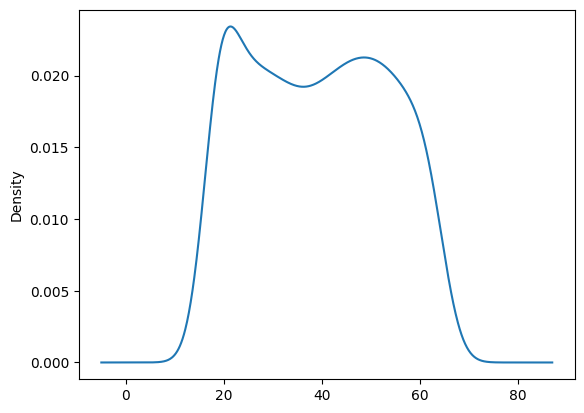

In [4]:
df['age'].plot(kind='kde')

### Q-2: What is the probability of a patient having a BMI greater than 30?

In [5]:
df[df['bmi']>30].shape[0]/df.shape[0]

0.5269058295964125

### Q-3: Plot distribution plot of claim for Smoker and non smoker. What changes you see in the plot?

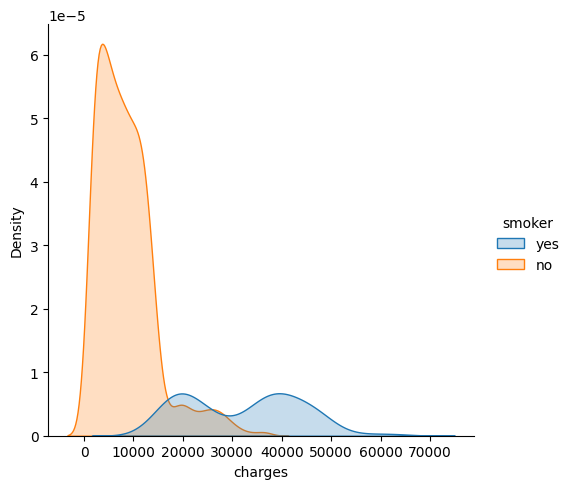

In [11]:
sns.displot(
    data=df,
    x='charges',
    hue='smoker',
    kind='kde',
    fill=True
)

plt.show()

### Q-4: Plot the 2D probability density plot of claim and age in the insurance dataset?

/tmp/ipykernel_611/1086905420.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


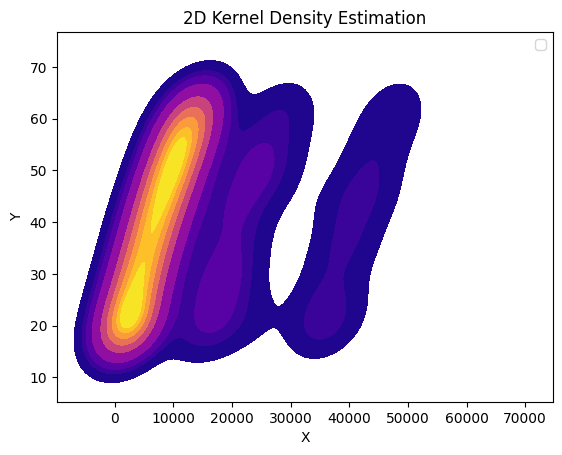

In [19]:
sns.kdeplot(data=df,x='charges', y='age', fill=True, cmap="plasma")
plt.title("2D Kernel Density Estimation")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

### Q-5: How does the disribution of claim changes for different region? Plot density plot and note down the observations

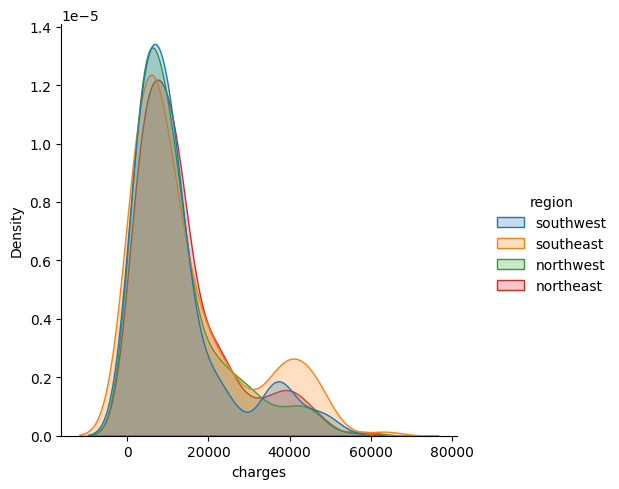

In [16]:
sns.displot(
    data=df,
    x='charges',
    hue='region',
    kind='kde',
    fill=True
)

plt.show()

### Q6: Plot PDF and CDF of claim in insurance data

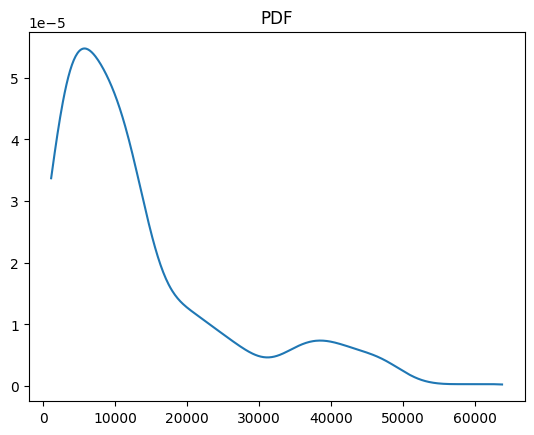

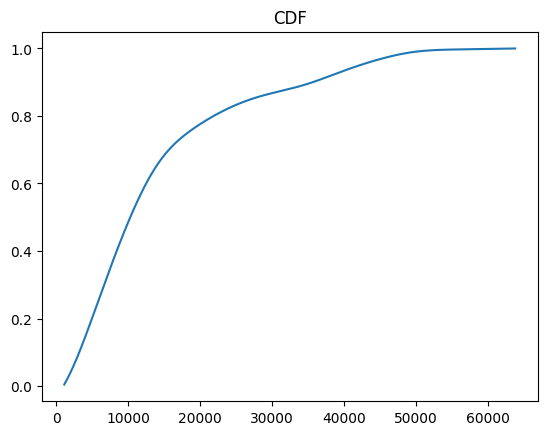

In [24]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

claims = df['charges']

x = np.linspace(claims.min(), claims.max(), 500)
kde = gaussian_kde(claims)

plt.plot(x, kde(x))
plt.title("PDF")
plt.show()

plt.plot(x, np.cumsum(kde(x))/np.sum(kde(x)))
plt.title("CDF")
plt.show()

### Q-7: Given a probability density function f(x) = 2x for 0 <= x <= 1 and f(x) = 0 otherwise, compute the cumulative distribution function F(x) and plot it. Use this to find the probability that X is greater than 0.5.

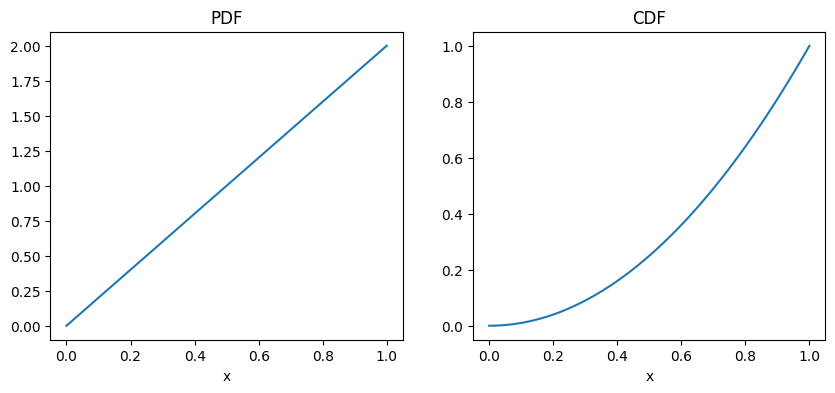

In [31]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,1,100)

pdf = 2*x
cdf = x**2

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(x,pdf)
plt.title("PDF")
plt.xlabel("x")

plt.subplot(1,2,2)
plt.plot(x,cdf)
plt.title("CDF")
plt.xlabel("x")

plt.show()

### Q-8: In a manufacturing process, the thickness of a certain material is known to be normally distributed with a mean of 1.2 mm and a standard deviation of 0.05 mm. What is the probability density function of the thickness? Plot the PDF and use it to compute the probability that the thickness is between 1.1 mm and 1.3 mm.

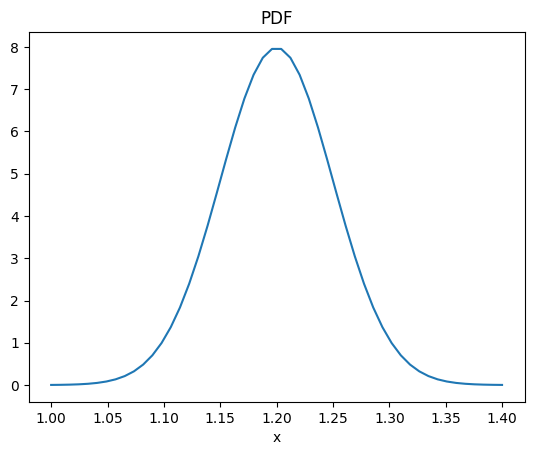

95.45


In [44]:
from scipy.stats import norm, t
x=np.linspace(1,1.4,50)
pdf = norm.pdf(x, 1.2, 0.05)
plt.plot(x, pdf)
plt.title("PDF")
plt.xlabel("x")
plt.show()
prob=round((norm.cdf(1.3, 1.2, 0.05)-norm.cdf(1.1, 1.2, 0.05))*100,2)
print(prob)

### Q-9 : A data scientist is investigating the distribution of customer ages in a retail store. She collects a sample of 100 ages and estimates the probability density function using kernel density estimation. What bandwidth should she choose to obtain the best estimate?

<Axes: xlabel='age', ylabel='Density'>

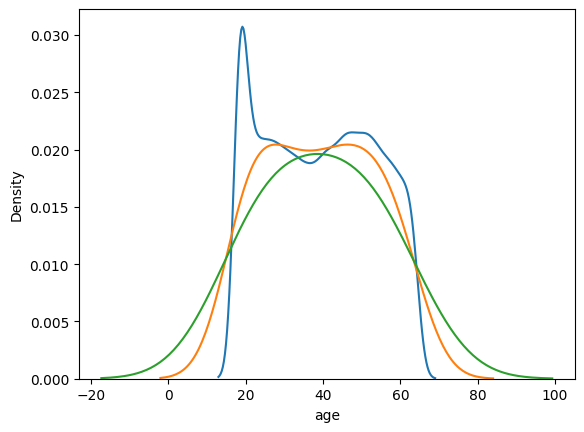

In [49]:
sns.kdeplot(df['age'], bw_adjust=0.5)   # smaller bandwidth
sns.kdeplot(df['age'], bw_adjust=2)     # larger bandwidth
# sns.kdeplot(df['age'], bw_adjust=25)
h=1.06*df['age'].std()*df['age'].count()**(-1/5)
sns.kdeplot(df['age'], bw_adjust=h)